In [4]:
# src/model_training/train_spike_attention_masked.py
import torch
import logging
import os
from datetime import datetime
import importlib
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from spikingjelly.activation_based import functional
from tqdm import tqdm

import src.model_training.model
importlib.reload(src.model_training.model)
from src.model_training.model import SpikeNet

In [5]:
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
)

logger = logging.getLogger(__name__)
# usage: logger.info("Starting training")

In [3]:
# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Initialize model
model = SpikeNet(
    in_dim=1611,      # Input feature dimension
    embed_dim=256,    # Embedding dimension
    num_classes=7,    # Number of output classes
    T=32,             # Number of timesteps (for SNN)
    dropout=0.1       # Dropout rate
).to(device)

# Print model summary (optional)
print(model)

# Example dummy input: batch_size=4, seq_len=8, feature_dim=1611
dummy_input = torch.randn(4, 8, 1611).to(device)

# Forward pass
model.eval()  # Set model to evaluation mode
with torch.no_grad():
    logits = model(dummy_input)

# Print output shape
print(f'Logits shape: {logits.shape}')  # Expected: (4, 7)

# Get predictions
preds = torch.argmax(logits, dim=1)
print(f'Predicted classes: {preds.cpu().numpy()}')


SpikeNet(
  (input_proj): Linear(in_features=1611, out_features=256, bias=False)
  (lif1): LIFNode(
    v_threshold=1.0, v_reset=0.0, detach_reset=True, step_mode=m, backend=torch, tau=2.0
    (surrogate_function): Sigmoid(alpha=4.0, spiking=True)
  )
  (fc1): Linear(in_features=256, out_features=256, bias=False)
  (lif2): LIFNode(
    v_threshold=1.0, v_reset=0.0, detach_reset=True, step_mode=m, backend=torch, tau=2.0
    (surrogate_function): Sigmoid(alpha=4.0, spiking=True)
  )
  (fc2): Linear(in_features=256, out_features=256, bias=False)
  (lif3): LIFNode(
    v_threshold=1.0, v_reset=0.0, detach_reset=True, step_mode=m, backend=torch, tau=2.0
    (surrogate_function): Sigmoid(alpha=4.0, spiking=True)
  )
  (dropout): Dropout(p=0.1)
  (classifier): Linear(in_features=256, out_features=7, bias=True)
)
Logits shape: torch.Size([4, 7])
Predicted classes: [1 1 1 1]


In [10]:
def train_spiking_network(
    train_loader,
    val_loader,
    in_dim=1611,
    num_classes=7,
    embed_dim=256,
    lr=1e-4,
    epochs=100,
    save_path="checkpoints_snn",
    T=32,
):
    """
    Training loop for SpikeNet model.
    
    Args:
        train_loader: Training data loader
        val_loader: Validation data loader
        in_dim: Input feature dimension
        num_classes: Number of output classes
        embed_dim: Embedding dimension
        lr: Learning rate
        epochs: Number of training epochs
        save_path: Path to save checkpoints
        T: Number of simulation timesteps
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    model = SpikeNet(
        in_dim=in_dim, 
        embed_dim=embed_dim, 
        num_classes=num_classes, 
        T=T
    ).to(device)

    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = ReduceLROnPlateau(
        optimizer, 
        mode='max', 
        factor=0.5, 
        patience=10, 
        min_lr=1e-6
    )

    # Logging Setup
    os.makedirs(save_path, exist_ok=True)
    
    logging.info(f"Using device: {device}")
    logging.info(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
    logging.info(f"Simulation timesteps per input: {T}")
    logging.info(f"Training config: lr={lr}, epochs={epochs}, batch_size={train_loader.batch_size}")

    best_val_acc = 0.0
    patience = 0
    max_patience = 20

    # Training Loop
    for epoch in range(1, epochs + 1):
        # Training Phase
        model.train()
        train_loss, train_acc = 0.0, 0.0
        train_samples = 0

        progress_bar = tqdm(train_loader, desc=f"Epoch {epoch:03d} [TRAIN]", disable=False)
        
        for batch_idx, (data, labels, mask) in enumerate(progress_bar):
            data = data.to(device)
            labels = labels.to(device)
            mask = mask.to(device) if mask is not None else None
            
            optimizer.zero_grad(set_to_none=True)

            # Reset neuron states
            functional.reset_net(model)

            # Forward pass
            logits = model(data, mask=mask)
            loss = criterion(logits, labels)

            # Backward pass
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            # Metrics
            batch_size = data.size(0)
            preds = logits.argmax(dim=1)
            batch_acc = (preds == labels).float().sum().item()
            
            train_loss += loss.item() * batch_size
            train_acc += batch_acc
            train_samples += batch_size

            progress_bar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'acc': f'{batch_acc / batch_size:.4f}'
            })

        avg_train_loss = train_loss / train_samples
        avg_train_acc = train_acc / train_samples

        # Validation Phase
        model.eval()
        val_loss, val_acc = 0.0, 0.0
        val_samples = 0

        progress_bar = tqdm(val_loader, desc=f"Epoch {epoch:03d} [VAL]", disable=False)
        
        with torch.no_grad():
            for data, labels, mask in progress_bar:
                data = data.to(device)
                labels = labels.to(device)
                mask = mask.to(device) if mask is not None else None

                # Reset neuron states
                functional.reset_net(model)

                # Forward pass
                logits = model(data, mask=mask)
                loss = criterion(logits, labels).to(device)

                batch_size = data.size(0)
                preds = logits.argmax(dim=1)
                batch_acc = (preds == labels).float().sum().item()
                
                val_loss += loss.item() * batch_size
                val_acc += batch_acc
                val_samples += batch_size

                progress_bar.set_postfix({
                    'loss': f'{loss.item():.4f}',
                    'acc': f'{batch_acc / batch_size:.4f}'
                })

        avg_val_loss = val_loss / val_samples
        avg_val_acc = val_acc / val_samples

        # Logging
        logging.info(
            f"Epoch {epoch:03d} | "
            f"Train Loss: {avg_train_loss:.4f} | Train Acc: {avg_train_acc:.4f} | "
            f"Val Loss: {avg_val_loss:.4f} | Val Acc: {avg_val_acc:.4f} | "
            f"LR: {optimizer.param_groups[0]['lr']:.2e}"
        )

        # Learning Rate Scheduling
        scheduler.step(avg_val_acc)
        current_lr = scheduler.get_last_lr()[0]

        # Early Stopping with Best Model Saving
        if avg_val_acc > best_val_acc:
            best_val_acc = avg_val_acc
            patience = 0
            
            checkpoint = {
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_acc': avg_val_acc,
                'val_loss': avg_val_loss,
            }
            torch.save(checkpoint, os.path.join(save_path, "best_model.pt"))
            logging.info(
                f"✅ New best model saved at epoch {epoch} | "
                f"Val Acc: {best_val_acc:.4f}"
            )
        else:
            patience += 1
            if patience >= max_patience:
                logging.info(f"⏸️  Early stopping triggered at epoch {epoch}")
                break

    logging.info(f"✓ Training completed. Best validation accuracy: {best_val_acc:.4f}")
    logging.info(f"Best model saved at: {os.path.join(save_path, 'best_model.pt')}")
    
    return model


def load_best_model(model, checkpoint_path):
    """Load best model checkpoint."""
    checkpoint = torch.load(checkpoint_path)
    model.load_state_dict(checkpoint['model_state_dict'])
    logging.info(f"Loaded best model from {checkpoint_path} (epoch {checkpoint['epoch']}, val_acc={checkpoint['val_acc']:.4f})")
    return model


In [11]:
import src.load_dataset.dataset
importlib.reload(src.load_dataset.dataset)
from src.load_dataset.dataset import create_balanced_splits

# Create data loaders with rebalancing
train_loader, val_loader, test_loader = create_balanced_splits(
    features_path="data/features/audio_embeddings_feature_selection_emotion.pkl",
    labels_path="data/features/data_emotion.p",
    batch_size=32,
    T=8,
    augment=True,
    use_weighted_sampling=True,  # This handles imbalance elegantly
    num_workers=4,
)


# Test a batch
print("🧪 Testing data loader...")
for spikes, labels, masks in train_loader:
    print(f"✓ Batch shape: spikes={spikes.shape}, labels={labels.shape}, masks={masks.shape}")
    print(f"✓ Unique labels in batch: {torch.unique(labels).tolist()}")
    break


📥 Loading data...
🔄 Processing features and labels...
✅ Loaded: 13708 samples, 1611 features

📊 FULL DATASET - CLASS IMBALANCE ANALYSIS
Total samples: 13708
Imbalance ratio (max/min): 17.98x

Class    Count      Percentage   Weight    
----------------------------------------------------------------------
0        6436        46.95% ███████████████      0.0002
1        1636        11.93% ███                  0.0006
2        358          2.61%                      0.0028
3        1003         7.32% ██                   0.0010
4        2308        16.84% █████                0.0004
5        361          2.63%                      0.0028
6        1606        11.72% ███                  0.0006

📊 Creating stratified splits...
📁 Train: 10966 | Val: 1371 | Test: 1371


📊 TRAINING SET - CLASS IMBALANCE ANALYSIS
Total samples: 10966
Imbalance ratio (max/min): 18.00x

Class    Count      Percentage   Weight    
----------------------------------------------------------------------
0        5149

In [12]:
import torch
from collections import Counter

def verify_weighted_sampling(train_loader, num_batches=10):
    """
    Verify that weighted sampling is balancing classes across batches.
    """
    print("\n" + "="*70)
    print("🔍 VERIFYING WEIGHTED SAMPLING")
    print("="*70 + "\n")
    
    batch_class_distribution = []
    
    for batch_idx, (spikes, labels, masks) in enumerate(train_loader):
        if batch_idx >= num_batches:
            break
        
        batch_classes = labels.cpu().numpy()
        batch_counts = Counter(batch_classes)
        batch_class_distribution.append(batch_counts)
        
        print(f"Batch {batch_idx:2d}: {dict(sorted(batch_counts.items()))}")
    
    # Aggregate across all batches
    aggregated = Counter()
    for batch_counts in batch_class_distribution:
        aggregated.update(batch_counts)
    
    total_samples = sum(aggregated.values())
    
    print(f"\n{'='*70}")
    print("AGGREGATED CLASS DISTRIBUTION (across first {num_batches} batches)")
    print(f"{'='*70}")
    print(f"Total samples: {total_samples}\n")
    
    print(f"{'Class':<8} {'Count':<10} {'Percentage':<12}")
    print("-" * 70)
    
    for cls in sorted(aggregated.keys()):
        count = aggregated[cls]
        pct = 100 * count / total_samples
        bar = "█" * int(pct / 2)
        print(f"{cls:<8} {count:<10} {pct:>6.2f}% {bar}")
    
    # Check if reasonably balanced
    counts_list = list(aggregated.values())
    expected_per_class = total_samples / 7  # 7 classes
    
    print(f"\n{'='*70}")
    print("BALANCE CHECK")
    print(f"{'='*70}")
    print(f"Expected per class: {expected_per_class:.1f}")
    print(f"Actual min: {min(counts_list)}")
    print(f"Actual max: {max(counts_list)}")
    print(f"Imbalance ratio: {max(counts_list) / min(counts_list):.2f}x\n")
    
    # Verdict
    if max(counts_list) / min(counts_list) < 2.0:
        print("✅ EXCELLENT: Classes are well-balanced!")
    elif max(counts_list) / min(counts_list) < 3.0:
        print("✓ GOOD: Classes are reasonably balanced")
    else:
        print("⚠️  WARNING: Classes still somewhat imbalanced")
    
    print(f"{'='*70}\n")

# Run verification
verify_weighted_sampling(train_loader, num_batches=20)



🔍 VERIFYING WEIGHTED SAMPLING

Batch  0: {np.int64(0): 4, np.int64(1): 4, np.int64(2): 6, np.int64(3): 5, np.int64(4): 4, np.int64(5): 5, np.int64(6): 4}
Batch  1: {np.int64(0): 5, np.int64(1): 9, np.int64(2): 3, np.int64(3): 2, np.int64(4): 5, np.int64(5): 3, np.int64(6): 5}
Batch  2: {np.int64(0): 7, np.int64(1): 2, np.int64(2): 6, np.int64(3): 3, np.int64(4): 5, np.int64(5): 2, np.int64(6): 7}
Batch  3: {np.int64(0): 3, np.int64(1): 4, np.int64(2): 6, np.int64(3): 5, np.int64(4): 4, np.int64(5): 4, np.int64(6): 6}
Batch  4: {np.int64(0): 10, np.int64(1): 5, np.int64(2): 1, np.int64(3): 6, np.int64(4): 1, np.int64(5): 4, np.int64(6): 5}
Batch  5: {np.int64(0): 9, np.int64(1): 3, np.int64(2): 1, np.int64(3): 5, np.int64(4): 5, np.int64(5): 6, np.int64(6): 3}
Batch  6: {np.int64(0): 3, np.int64(1): 5, np.int64(2): 4, np.int64(3): 6, np.int64(4): 8, np.int64(5): 1, np.int64(6): 5}
Batch  7: {np.int64(0): 9, np.int64(1): 2, np.int64(2): 3, np.int64(3): 1, np.int64(4): 6, np.int64(5): 5,

In [13]:
# Done: Pass to your training function
# Training
# Train the model
model = train_spiking_network(
    train_loader=train_loader,
    val_loader=val_loader,
    in_dim=1611,
    num_classes=7,
    embed_dim=256,
    lr=1e-3,
    epochs=50,
    save_path="checkpoints_snn",
    T=32,  # Should match dataset T and model T
)
# Loading best model
best_model = SpikeNet(in_dim=1611, embed_dim=256, num_classes=7, T=32).to(torch.device("cuda" if torch.cuda.is_available() else "cpu"))
best_model = load_best_model(best_model, "checkpoints_snn/best_model.pt")


Epoch 022 [VAL]: 100%|██████████| 43/43 [00:14<00:00,  2.93it/s, loss=1.9464, acc=0.1481]


📂 Loading model from checkpoints_snn/best_model.pt...
🔍 Evaluating model...


Evaluating: 100%|██████████| 43/43 [00:13<00:00,  3.17it/s]



✅ Evaluation complete!
   Test Loss: 1.9346
   Test Accuracy: 0.4697

📊 GENERATING EVALUATION PLOTS

1️⃣  Plotting confusion matrix...
✅ Confusion matrix saved to evaluation_results\01_confusion_matrix.png


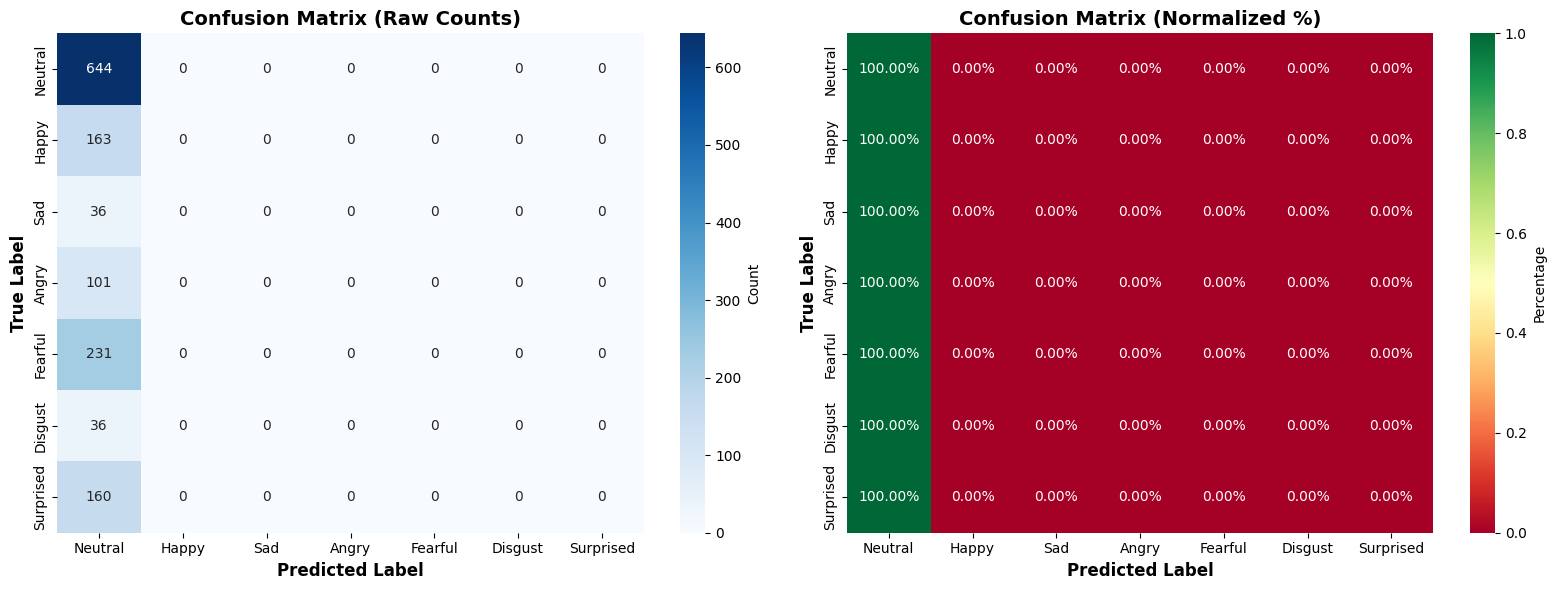

2️⃣  Plotting per-class metrics...


c:\Users\Marc\anaconda3\envs\snn-gpu\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


✅ Per-class metrics saved to evaluation_results\02_per_class_metrics.png


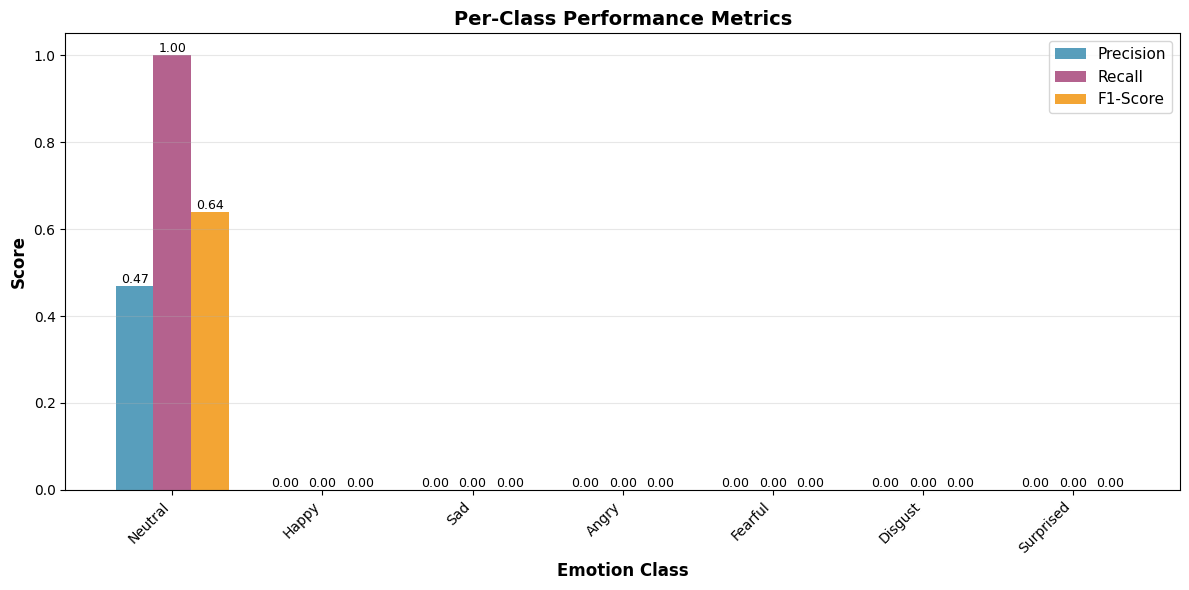

3️⃣  Plotting per-class accuracy...
✅ Per-class accuracy plot saved to evaluation_results\03_per_class_accuracy.png


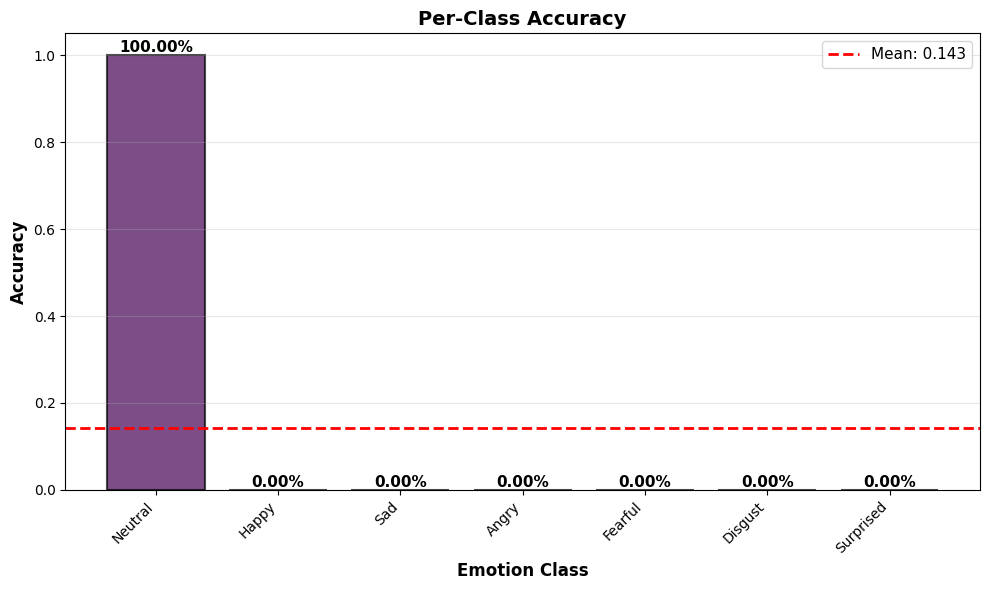

5️⃣  Generating classification report...

              precision    recall  f1-score   support

     Neutral     0.4697    1.0000    0.6392       644
       Happy     0.0000    0.0000    0.0000       163
         Sad     0.0000    0.0000    0.0000        36
       Angry     0.0000    0.0000    0.0000       101
     Fearful     0.0000    0.0000    0.0000       231
     Disgust     0.0000    0.0000    0.0000        36
   Surprised     0.0000    0.0000    0.0000       160

    accuracy                         0.4697      1371
   macro avg     0.0671    0.1429    0.0913      1371
weighted avg     0.2206    0.4697    0.3003      1371


✅ All plots saved to: evaluation_results


c:\Users\Marc\anaconda3\envs\snn-gpu\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Marc\anaconda3\envs\snn-gpu\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Marc\anaconda3\envs\snn-gpu\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.sh

In [14]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_fscore_support
from spikingjelly.activation_based import functional
from tqdm import tqdm
import json
import os


# =====================================
# Evaluation Function
# =====================================
def evaluate_model(model, dataloader, device, num_classes=7):
    """
    Evaluate model on a dataset and return all predictions, labels, and logits.
    
    Returns:
        all_preds: Predicted class indices
        all_labels: Ground truth labels
        all_logits: Raw model outputs
    """
    model.eval()
    all_preds = []
    all_labels = []
    all_logits = []
    total_loss = 0.0
    
    criterion = nn.CrossEntropyLoss()
    
    with torch.no_grad():
        for spikes, labels, masks in tqdm(dataloader, desc="Evaluating"):
            spikes = spikes.to(device)
            labels = labels.to(device)
            masks = masks.to(device) if masks is not None else None
            
            # Reset neuron states
            functional.reset_net(model)
            
            # Forward pass
            logits = model(spikes, mask=masks)
            loss = criterion(logits, labels)
            
            # Store results
            preds = logits.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_logits.extend(logits.cpu().numpy())
            total_loss += loss.item() * spikes.size(0)
    
    avg_loss = total_loss / len(dataloader.dataset)
    
    return (
        np.array(all_preds),
        np.array(all_labels),
        np.array(all_logits),
        avg_loss
    )


# =====================================
# Training Metrics Tracking
# =====================================
class TrainingMetrics:
    """Tracks training and validation metrics across epochs."""
    
    def __init__(self):
        self.train_losses = []
        self.train_accs = []
        self.val_losses = []
        self.val_accs = []
        self.epochs = []
    
    def add_epoch(self, epoch, train_loss, train_acc, val_loss, val_acc):
        """Record metrics for an epoch."""
        self.epochs.append(epoch)
        self.train_losses.append(train_loss)
        self.train_accs.append(train_acc)
        self.val_losses.append(val_loss)
        self.val_accs.append(val_acc)
    
    def save(self, filepath):
        """Save metrics to JSON."""
        metrics_dict = {
            'epochs': self.epochs,
            'train_losses': self.train_losses,
            'train_accs': self.train_accs,
            'val_losses': self.val_losses,
            'val_accs': self.val_accs,
        }
        with open(filepath, 'w') as f:
            json.dump(metrics_dict, f, indent=2)
    
    def load(self, filepath):
        """Load metrics from JSON."""
        with open(filepath, 'r') as f:
            metrics_dict = json.load(f)
        self.epochs = metrics_dict['epochs']
        self.train_losses = metrics_dict['train_losses']
        self.train_accs = metrics_dict['train_accs']
        self.val_losses = metrics_dict['val_losses']
        self.val_accs = metrics_dict['val_accs']


# =====================================
# Visualization Functions
# =====================================
def plot_confusion_matrix(y_true, y_pred, label_names, save_path=None):
    """
    Plot and display confusion matrix.
    
    Args:
        y_true: Ground truth labels
        y_pred: Predicted labels
        label_names: List of emotion class names
        save_path: Path to save figure (optional)
    """
    # Compute confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    
    # Normalize by row (per true label)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    # Create figure
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Plot 1: Raw counts
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=label_names,
        yticklabels=label_names,
        ax=axes[0],
        cbar_kws={'label': 'Count'}
    )
    axes[0].set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('True Label', fontsize=12, fontweight='bold')
    axes[0].set_title('Confusion Matrix (Raw Counts)', fontsize=14, fontweight='bold')
    
    # Plot 2: Normalized (percentages)
    sns.heatmap(
        cm_normalized,
        annot=True,
        fmt='.2%',
        cmap='RdYlGn',
        xticklabels=label_names,
        yticklabels=label_names,
        ax=axes[1],
        cbar_kws={'label': 'Percentage'},
        vmin=0,
        vmax=1
    )
    axes[1].set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('True Label', fontsize=12, fontweight='bold')
    axes[1].set_title('Confusion Matrix (Normalized %)', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✅ Confusion matrix saved to {save_path}")
    
    plt.show()
    return cm, cm_normalized


def plot_per_class_metrics(y_true, y_pred, label_names, save_path=None):
    """
    Plot per-class precision, recall, and F1-score.
    
    Args:
        y_true: Ground truth labels
        y_pred: Predicted labels
        label_names: List of emotion class names
        save_path: Path to save figure (optional)
    """
    # Compute metrics
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, average=None
    )
    
    # Create figure
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # X-axis positions
    x = np.arange(len(label_names))
    width = 0.25
    
    # Plot bars
    bars1 = ax.bar(x - width, precision, width, label='Precision', alpha=0.8, color='#2E86AB')
    bars2 = ax.bar(x, recall, width, label='Recall', alpha=0.8, color='#A23B72')
    bars3 = ax.bar(x + width, f1, width, label='F1-Score', alpha=0.8, color='#F18F01')
    
    # Labels and title
    ax.set_xlabel('Emotion Class', fontsize=12, fontweight='bold')
    ax.set_ylabel('Score', fontsize=12, fontweight='bold')
    ax.set_title('Per-Class Performance Metrics', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(label_names, rotation=45, ha='right')
    ax.legend(fontsize=11)
    ax.set_ylim([0, 1.05])
    ax.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for bars in [bars1, bars2, bars3]:
        for bar in bars:
            height = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width() / 2.,
                height,
                f'{height:.2f}',
                ha='center',
                va='bottom',
                fontsize=9
            )
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✅ Per-class metrics saved to {save_path}")
    
    plt.show()
    return precision, recall, f1, support


def plot_per_class_accuracy(y_true, y_pred, label_names, save_path=None):
    """
    Plot accuracy per class (recall).
    
    Args:
        y_true: Ground truth labels
        y_pred: Predicted labels
        label_names: List of emotion class names
        save_path: Path to save figure (optional)
    """
    # Compute per-class accuracy (recall)
    accuracies = []
    for i, label_name in enumerate(label_names):
        mask = y_true == i
        if mask.sum() > 0:
            class_acc = (y_pred[mask] == i).sum() / mask.sum()
            accuracies.append(class_acc)
        else:
            accuracies.append(0)
    
    # Create figure
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Plot bars with color gradient
    colors = plt.cm.viridis(np.linspace(0, 1, len(label_names)))
    bars = ax.bar(label_names, accuracies, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
    
    # Labels and title
    ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
    ax.set_xlabel('Emotion Class', fontsize=12, fontweight='bold')
    ax.set_title('Per-Class Accuracy', fontsize=14, fontweight='bold')
    ax.set_ylim([0, 1.05])
    ax.axhline(y=np.mean(accuracies), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(accuracies):.3f}')
    ax.grid(axis='y', alpha=0.3)
    ax.legend(fontsize=11)
    
    # Add value labels on bars
    for bar, acc in zip(bars, accuracies):
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2.,
            height,
            f'{acc:.2%}',
            ha='center',
            va='bottom',
            fontsize=11,
            fontweight='bold'
        )
    
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✅ Per-class accuracy plot saved to {save_path}")
    
    plt.show()
    return accuracies


def plot_training_curves(metrics, save_path=None):
    """
    Plot training and validation loss/accuracy curves.
    
    Args:
        metrics: TrainingMetrics object
        save_path: Path to save figure (optional)
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot 1: Loss curves
    axes[0].plot(metrics.epochs, metrics.train_losses, 'o-', linewidth=2, markersize=6, label='Train Loss', color='#2E86AB')
    axes[0].plot(metrics.epochs, metrics.val_losses, 's-', linewidth=2, markersize=6, label='Val Loss', color='#A23B72')
    axes[0].set_xlabel('Epoch', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Loss', fontsize=12, fontweight='bold')
    axes[0].set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
    axes[0].legend(fontsize=11)
    axes[0].grid(alpha=0.3)
    
    # Plot 2: Accuracy curves
    axes[1].plot(metrics.epochs, metrics.train_accs, 'o-', linewidth=2, markersize=6, label='Train Accuracy', color='#2E86AB')
    axes[1].plot(metrics.epochs, metrics.val_accs, 's-', linewidth=2, markersize=6, label='Val Accuracy', color='#A23B72')
    axes[1].set_xlabel('Epoch', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Accuracy', fontsize=12, fontweight='bold')
    axes[1].set_title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
    axes[1].legend(fontsize=11)
    axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✅ Training curves saved to {save_path}")
    
    plt.show()


def plot_class_distribution(y, label_names, dataset_name="Dataset", save_path=None):
    """
    Plot class distribution.
    
    Args:
        y: Labels array
        label_names: List of emotion class names
        dataset_name: Name of dataset (for title)
        save_path: Path to save figure (optional)
    """
    from collections import Counter
    
    class_counts = Counter(y)
    counts = [class_counts[i] for i in range(len(label_names))]
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    colors = plt.cm.Set3(np.linspace(0, 1, len(label_names)))
    bars = ax.bar(label_names, counts, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
    
    ax.set_ylabel('Count', fontsize=12, fontweight='bold')
    ax.set_xlabel('Emotion Class', fontsize=12, fontweight='bold')
    ax.set_title(f'{dataset_name} - Class Distribution', fontsize=14, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for bar, count in zip(bars, counts):
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2.,
            height,
            f'{int(count)}',
            ha='center',
            va='bottom',
            fontsize=11,
            fontweight='bold'
        )
    
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✅ Class distribution plot saved to {save_path}")
    
    plt.show()


def plot_all_metrics(y_true, y_pred, label_names, metrics=None, output_dir="results"):
    """
    Generate and save all evaluation plots.
    
    Args:
        y_true: Ground truth labels
        y_pred: Predicted labels
        label_names: List of emotion class names
        metrics: TrainingMetrics object (optional)
        output_dir: Directory to save plots
    """
    os.makedirs(output_dir, exist_ok=True)
    
    print("\n" + "="*50)
    print("📊 GENERATING EVALUATION PLOTS")
    print("="*50 + "\n")
    
    # 1. Confusion Matrix
    print("1️⃣  Plotting confusion matrix...")
    plot_confusion_matrix(
        y_true, y_pred, label_names,
        save_path=os.path.join(output_dir, "01_confusion_matrix.png")
    )
    
    # 2. Per-Class Metrics
    print("2️⃣  Plotting per-class metrics...")
    plot_per_class_metrics(
        y_true, y_pred, label_names,
        save_path=os.path.join(output_dir, "02_per_class_metrics.png")
    )
    
    # 3. Per-Class Accuracy
    print("3️⃣  Plotting per-class accuracy...")
    plot_per_class_accuracy(
        y_true, y_pred, label_names,
        save_path=os.path.join(output_dir, "03_per_class_accuracy.png")
    )
    
    # 4. Training Curves (if metrics provided)
    if metrics is not None:
        print("4️⃣  Plotting training curves...")
        plot_training_curves(
            metrics,
            save_path=os.path.join(output_dir, "04_training_curves.png")
        )
    
    # 5. Classification Report
    print("5️⃣  Generating classification report...")
    report = classification_report(y_true, y_pred, target_names=label_names, digits=4)
    print("\n" + report)
    
    with open(os.path.join(output_dir, "classification_report.txt"), 'w') as f:
        f.write(report)
    
    print("\n✅ All plots saved to:", output_dir)


# =====================================
# Complete Evaluation Pipeline
# =====================================
def full_evaluation(
    model,
    test_loader,
    device,
    label_names,
    metrics=None,
    checkpoint_path=None,
    output_dir="results"
):
    """
    Complete evaluation pipeline: load model, evaluate, generate all plots.
    
    Args:
        model: Model to evaluate
        test_loader: Test DataLoader
        device: Device (cuda or cpu)
        label_names: List of emotion class names
        metrics: TrainingMetrics object (optional)
        checkpoint_path: Path to model checkpoint to load (optional)
        output_dir: Directory to save results
    """
    
    # Load checkpoint if provided
    if checkpoint_path:
        print(f"📂 Loading model from {checkpoint_path}...")
        checkpoint = torch.load(checkpoint_path, map_location=device)
        model.load_state_dict(checkpoint['model_state_dict'])
    
    model.to(device)
    
    # Evaluate
    print("🔍 Evaluating model...")
    preds, labels, logits, loss = evaluate_model(model, test_loader, device)
    
    print(f"\n✅ Evaluation complete!")
    print(f"   Test Loss: {loss:.4f}")
    print(f"   Test Accuracy: {(preds == labels).mean():.4f}")
    
    # Generate all plots
    plot_all_metrics(
        labels, preds, label_names, 
        metrics=metrics,
        output_dir=output_dir
    )
    
    return preds, labels, logits


# =====================================
# Usage Example
# =====================================
if __name__ == "__main__":
    # Define label names
    label_names = ["Neutral", "Happy", "Sad", "Angry", "Fearful", "Disgust", "Surprised"]
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # metrics.load("path/to/metrics.json")
    
    # Run full evaluation
    preds, labels, logits = full_evaluation(
        model=model,
        test_loader=test_loader,  # Your test DataLoader
        device=device,
        label_names=label_names,
        metrics=None,
        checkpoint_path="checkpoints_snn/best_model.pt",
        output_dir="evaluation_results"
    )


In [15]:
# Save only model weights (state_dict)
torch.save(model.state_dict(), "snn_best_model.pth")